In [1]:
import numpy as np

class ArtificialBeeColony:
    def __init__(self, objective_function, num_food_sources=20, num_dimensions=2, max_iterations=100, limit=10, bounds=(-5, 5)):
        """
        Initialize the ABC algorithm.

        Parameters:
            objective_function (callable): The objective function to minimize.
            num_food_sources (int): Number of food sources (candidate solutions).
            num_dimensions (int): Number of dimensions in the search space.
            max_iterations (int): Maximum number of iterations.
            limit (int): Abandonment limit for scout bees.
            bounds (tuple): Lower and upper bounds for the search space.
        """
        self.objective_function = objective_function
        self.num_food_sources = num_food_sources
        self.num_dimensions = num_dimensions
        self.max_iterations = max_iterations
        self.limit = limit
        self.bounds = bounds

        # Initialize food sources (candidate solutions)
        self.food_sources = np.random.uniform(self.bounds[0], self.bounds[1], (self.num_food_sources, self.num_dimensions))
        self.fitness_values = np.zeros(self.num_food_sources)
        self.trials = np.zeros(self.num_food_sources)
        self.best_solution = None
        self.best_fitness = float('inf')

    def fitness(self, f):
        """
        Calculate the fitness of a solution.

        Parameters:
            f (float): Objective function value.

        Returns:
            float: Fitness value.
        """
        return 1 / (1 + f) if f >= 0 else 1 + abs(f)

    def evaluate_fitness(self):
        """
        Evaluate the fitness of all food sources.
        """
        for i in range(self.num_food_sources):
            f = self.objective_function(self.food_sources[i])
            self.fitness_values[i] = self.fitness(f)
            if f < self.best_fitness:
                self.best_fitness = f
                self.best_solution = self.food_sources[i].copy()

    def employed_bee_phase(self):
        """
        Employed bee phase: Explore new solutions around existing food sources.
        """
        for i in range(self.num_food_sources):
            # Select a random neighbor
            # Select a random dimension
            # TODO
            k = np.random.choice([x for x in range(self.num_food_sources) if x != i])
            j = np.random.randint(0, self.num_dimensions)
            
            # Generate a new solution
            # TODO 
            phi = np.random.uniform(-1, 1)
            new_solution = self.food_sources[i].copy()
            new_solution[j] = self.food_sources[i][j] + phi * (self.food_sources[i][j] - self.food_sources[k][j])

            # Clip the solution to stay within bounds
            # TODO
            new_solution = np.clip(new_solution, self.bounds[0], self.bounds[1])

            # Evaluate the new solution
            # TODO
            f_new = self.objective_function(new_solution)
            fitness_new = self.fitness(f_new)

           # Greedy selection
            # 如果新解更好，就更新
            if fitness_new > self.fitness_values[i]:
                self.food_sources[i] = new_solution  # 更新食物來源
                self.fitness_values[i] = fitness_new  # 更新 fitness
                self.trials[i] = 0  # 成功找到更好解，重置 trials
            else:
                self.trials[i] += 1  # 沒有改進，trial +1

    def onlooker_bee_phase(self):
        probabilities = self.fitness_values / np.sum(self.fitness_values)
    
        for _ in range(self.num_food_sources):
            # 用機率選一個 food source
            i = np.random.choice(range(self.num_food_sources), p=probabilities)
    
            k = np.random.choice([x for x in range(self.num_food_sources) if x != i])
            j = np.random.randint(0, self.num_dimensions)
    
            phi = np.random.uniform(-1, 1)
    
            new_solution = self.food_sources[i].copy()
            new_solution[j] = self.food_sources[i][j] + phi * (self.food_sources[i][j] - self.food_sources[k][j])
    
            new_solution = np.clip(new_solution, self.bounds[0], self.bounds[1])
    
            f_new = self.objective_function(new_solution)
            fitness_new = self.fitness(f_new)
    
            if fitness_new > self.fitness_values[i]:
                self.food_sources[i] = new_solution
                self.fitness_values[i] = fitness_new
                self.trials[i] = 0
            else:
                self.trials[i] += 1

    def scout_bee_phase(self):
        """
        Scout bee phase: Replace abandoned food sources with new random solutions. # 避免演算法陷入局部最佳
        """
        for i in range(self.num_food_sources):
            if self.trials[i] > self.limit:
                # TODO 
                # 生成新的隨機解
                self.food_sources[i] = np.random.uniform(self.bounds[0], self.bounds[1], self.num_dimensions)
                # 計算新解的 fitness
                f_new = self.objective_function(self.food_sources[i])
                self.fitness_values[i] = self.fitness(f_new)
                # 重置 trials
                self.trials[i] = 0

    def optimize(self):
        """
        Run the ABC optimization algorithm.

        Returns:
            tuple: Best solution and best fitness value.
        """
        self.evaluate_fitness()  # Evaluate initial fitness
        
        history = []

        for iteration in range(self.max_iterations):
            self.employed_bee_phase()
            self.onlooker_bee_phase()
            self.scout_bee_phase()
            self.evaluate_fitness()  # Update best solution
            
            #記錄每一代最佳值
            history.append(self.best_fitness)
            
           # print(f"Iteration {iteration + 1}: Best Fitness = {self.best_fitness}")

        return self.best_solution, self.best_fitness, history

In [2]:
def rastrigin(x):
    # x 是一個 numpy 陣列，長度就是維度 (n_var)
    n = len(x)
    # np.sum 會把陣列裡所有元素加總，對應公式裡的 sigma (Σ)
    return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

def ackley(x):
    x = np.asarray(x, dtype=float)
    n = x.size 
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2.0 * np.pi * x))
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
    term2 = -np.exp(sum_cos / n)
    return float(term1 + term2 + 20.0 + np.e)

def schwefel(x):
    x = np.asarray(x, dtype=float)
    n = x.size 
    return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

def rosenbrock(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))


🚀ABC Running rastrigin benchmark(30 runs)

📊 rastrigin Summary
  Mean Best Score: 0.000000e+00 ± 0.00e+00
  Mean Best Position: [-0. -0.  0.]
  Mean Time: 8.3927 sec

🚀ABC Running ackley benchmark(30 runs)

📊 ackley Summary
  Mean Best Score: 4.440892e-16 ± 0.00e+00
  Mean Best Position: [-0.  0.  0.]
  Mean Time: 10.7368 sec

🚀ABC Running schwefel benchmark(30 runs)

📊 schwefel Summary
  Mean Best Score: 3.818270e-05 ± 0.00e+00
  Mean Best Position: [420.9687 420.9687 420.9687]
  Mean Time: 9.4489 sec

🚀ABC Running rosenbrock benchmark(30 runs)

📊 rosenbrock Summary
  Mean Best Score: 7.187279e-03 ± 7.55e-03
  Mean Best Position: [1.0006 1.0017 1.0058]
  Mean Time: 9.6338 sec


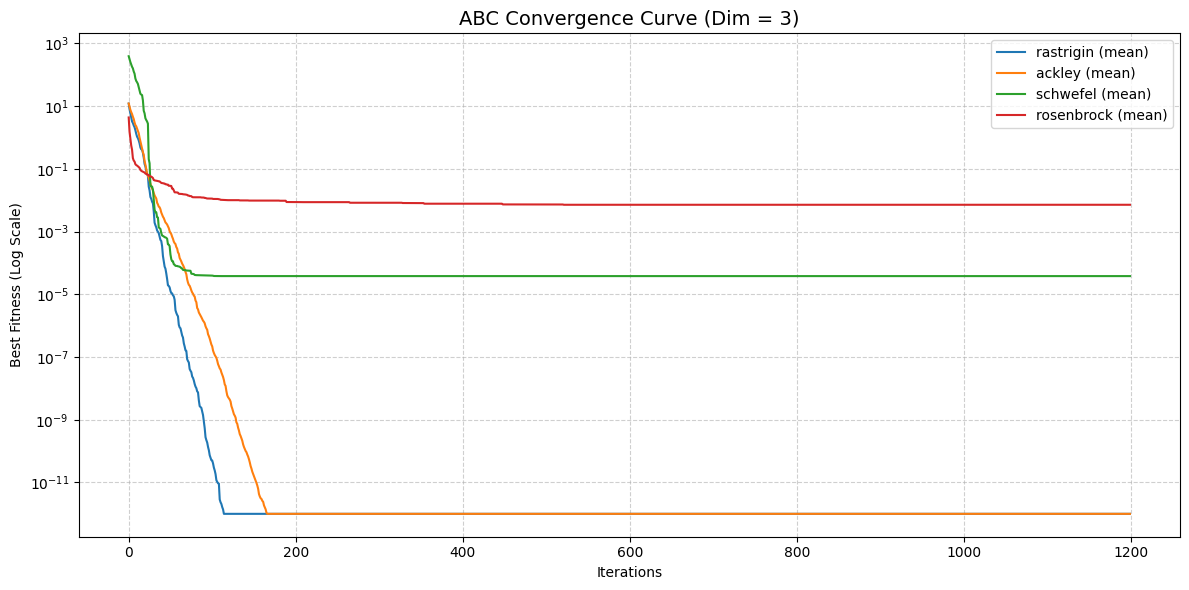

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

def run_abc_benchmark():
    dimension = 3
    iteration = 1200
    pop_size = 60
    runs = 30

    test_cases = {
        "rastrigin": (-5.12, 5.12),   # 0,(0,0,0)
        "ackley": (-32.768, 32.768),  # 0,(0,0,0)
        "schwefel": (-500.0, 500.0),  # 0,(420,420,420)
        "rosenbrock": (-2.048, 2.048) # 0,(1,1,1)
    }

    plt.figure(figsize=(12, 6))

    for func_name, bounds in test_cases.items():
        print(f"\n🚀ABC Running {func_name} benchmark({runs} runs)")

        all_histories = []
        final_scores = []
        final_positions = []
        times = []

        for run in range(runs):
            #print(f"\n  ▶ Run {run+1}/{runs}")
            np.random.seed(run)
            start_time = time.time()
           
            optimizer = ArtificialBeeColony(
                objective_function=func_dict(func_name),
                num_food_sources=pop_size,
                num_dimensions=dimension,
                max_iterations=iteration,
                bounds=bounds,
                limit=(pop_size * dimension) // 2 
            )
            
            best_solution, best_fitness, history = optimizer.optimize()

            elapsed = time.time() - start_time

            #Print results for each run
            #print(f"    Best Score: {optimizer.best_fitness:.6e}")
            #print(f"    Best Position: {np.round(optimizer.best_solution, 4)}")
            #print(f"    Time: {elapsed:.4f} sec")

            all_histories.append(history)
            final_scores.append(best_fitness)
            final_positions.append(best_solution)
            times.append(elapsed)

        # ===== statistics =====
        all_histories = np.array(all_histories)

        mean_curve = np.mean(all_histories, axis=0)
        mean_score = np.mean(final_scores)
        std_score = np.std(final_scores)
        mean_time = np.mean(times)
        mean_position = np.mean(final_positions, axis=0)

        print(f"\n📊 {func_name} Summary")
        print(f"  Mean Best Score: {mean_score:.6e} ± {std_score:.2e}")
        print(f"  Mean Best Position: {np.round(mean_position, 4)}")
        print(f"  Mean Time: {mean_time:.4f} sec")

        # avoid log(0)
        mean_curve = np.maximum(mean_curve, 1e-12)
        plt.plot(mean_curve, label=f"{func_name} (mean)")

    plt.title(f"ABC Convergence Curve (Dim = {dimension})", fontsize=14)
    plt.xlabel("Iterations")
    plt.ylabel("Best Fitness (Log Scale)")
    plt.yscale("log")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
   
       
            
def func_dict(name):
    if name == "rastrigin":
        return rastrigin
    elif name == "ackley":
        return ackley
    elif name == "schwefel":
        return schwefel
    elif name == "rosenbrock":
        return rosenbrock
    else:
        raise ValueError("Unknown function")
    
if __name__ == "__main__":
    run_abc_benchmark()